# 场景 2：`.ipynb` + R kernel

523 的 8 讲讲义就是这种文件。

**开始前**：点右上角的 kernel 选择器 → `Jupyter Kernel` → 选 **R 4.6.1**。
如果没看到这一项，说明 kernel 没注册好。

**操作**：
- `⇧Enter` 跑当前 cell 并跳下一个
- `⌘Enter` 跑当前 cell，原地不动
- `Esc` 再按 `b` 在下面插一个新 cell，按 `m` 把 cell 变成 markdown

In [ ]:
# 先确认真的是 R 在跑，h不是 Python
R.version.string

[1] "R version 4.6.1 (2026-06-24)"

## data.frame 会渲染成表格

这是 notebook 比 `.R` 脚本好的地方——输出直接排版好，不是一堆文本。

In [2]:
library(tidyverse)

mtcars |>
  rownames_to_column("car") |>
  filter(cyl == 4) |>
  select(car, mpg, wt, hp) |>
  arrange(desc(mpg))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


car,mpg,wt,hp
<chr>,<dbl>,<dbl>,<dbl>
Toyota Corolla,33.9,1.835,65
Fiat 128,32.4,2.200,66
Honda Civic,30.4,1.615,52
Lotus Europa,30.4,1.513,113
Fiat X1-9,27.3,1.935,66
Porsche 914-2,26.0,2.140,91
Merc 240D,24.4,3.190,62
Datsun 710,22.8,2.320,93
Merc 230,22.8,3.150,95


## 图直接嵌在 cell 下面

不需要 httpgd，notebook 自己会把图渲染进输出。
`repr.plot.width/height` 是 IRkernel 控制图大小的选项，RStudio 里没有这个。

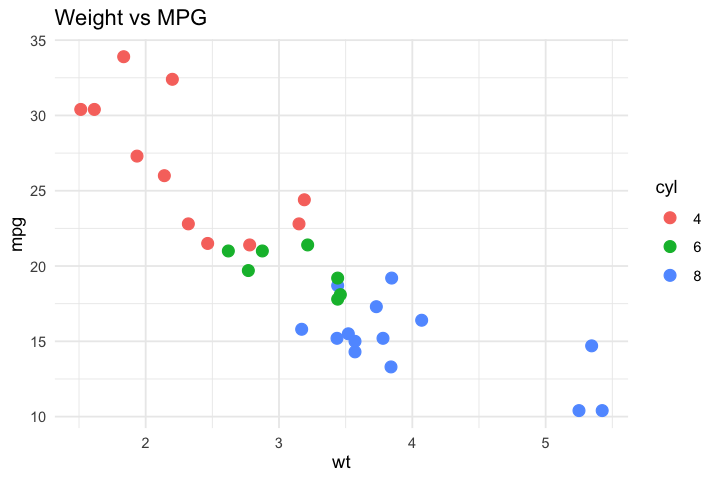

In [3]:
options(repr.plot.width = 6, repr.plot.height = 4)

ggplot(mtcars, aes(x = wt, y = mpg, colour = factor(cyl))) +
  geom_point(size = 3) +
  labs(title = "Weight vs MPG", colour = "cyl") +
  theme_minimal()

## 状态跨 cell 保留

下面这个 cell 定义变量，再下一个用它。跟 `.R` 终端一样，是同一个进程。

**但注意**：这个 notebook 的 R 进程，和 `1-r-script/demo.R` 用的那个 R 终端
是**两个完全独立的进程**。这边定义的变量，那边看不到。

In [4]:
top_cars <- mtcars |>
  rownames_to_column("car") |>
  slice_max(mpg, n = 5)

nrow(top_cars)

[1] 5

In [5]:
top_cars$car

[1] "Toyota Corolla" "Fiat 128"       "Honda Civic"    "Lotus Europa"  
[5] "Fiat X1-9"

## 报错长什么样

下面这个 cell 是**故意写错的**。跑一下看看错误怎么显示——
报错会留在 cell 下面，但**不会中断**你继续跑后面的 cell。

In [6]:
this_function_does_not_exist(1, 2, 3)

ERROR: Error in this_function_does_not_exist(1, 2, 3): could not find function "this_function_does_not_exist"


## 重启 kernel

改了函数定义、或者状态乱了，就重启：顶部工具栏的 **Restart**。
重启后所有变量清空，要从头再跑一遍。

验证：重启 kernel，然后**跳过前面所有 cell**直接跑下面这个，
应该返回 `FALSE`。

In [ ]:
exists("top_cars")